# ResNet-18

## Changes from Naive Baseline

### What changed
| | Naive | Unfreeze |
|---|---|---|
| Backbone | Frozen (only FC trains) | Unfrozen (all layers train) |
| Optimizer scope | `model.fc.parameters()` | `model.parameters()` |
| Learning rate | `1e-3` | `1e-4` |

### Rationale
In the naive version, the ResNet backbone was frozen — only the final classification layer (513 parameters out of ~11M) was trained. The backbone weights were fixed at ImageNet features, which are general-purpose and not specific to skin lesions.

By unfreezing the backbone, all ~11M parameters are fine-tuned on the HAM10000 dataset, allowing the model to adapt its feature extraction to the medical imaging domain.

A lower learning rate (`1e-4`) is used to avoid destroying the pretrained weights with large gradient updates early in training — the goal is to make small, careful adjustments to already-useful features rather than learning from scratch.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('../data/splits/train.csv')

num_melanoma = (train_df['label'] == 0).sum()   # melanoma in CSV
num_nevus = (train_df['label'] == 1).sum()      # nevus in CSV

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Positive weight: tensor([6.0244], device='mps:0')


In [5]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/resnet_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.6869, Acc: 0.7696, Recall: 0.8601, F2: 0.6784 | Val Loss: 0.6916, Acc: 0.7792, Recall: 0.8623, F2: 0.6870
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.5217, Acc: 0.8476, Recall: 0.8883, F2: 0.7596 | Val Loss: 0.6619, Acc: 0.8738, Recall: 0.7725, F2: 0.7111
Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.4437, Acc: 0.8719, Recall: 0.9101, F2: 0.7956 | Val Loss: 0.6490, Acc: 0.8764, Recall: 0.7725, F2: 0.7135
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.3760, Acc: 0.9008, Recall: 0.9358, F2: 0.8402 | Val Loss: 0.6441, Acc: 0.8892, Recall: 0.7305, F2: 0.6971


Epoch [5/20] | Train Loss: 0.3382, Acc: 0.9083, Recall: 0.9320, F2: 0.8460 | Val Loss: 0.7009, Acc: 0.8824, Recall: 0.7725, F2: 0.7191
Saved best model at epoch 5


...

Epoch [16/20] | Train Loss: 0.1034, Acc: 0.9762, Recall: 0.9807, F2: 0.9562 | Val Loss: 0.8583, Acc: 0.9156, Recall: 0.7605, F2: 0.7436
Saved best model at epoch 16


Epoch [17/20] | Train Loss: 0.0936, Acc: 0.9766, Recall: 0.9820, F2: 0.9574 | Val Loss: 1.0849, Acc: 0.8968, Recall: 0.7725, F2: 0.7330


Epoch [18/20] | Train Loss: 0.0987, Acc: 0.9761, Recall: 0.9872, F2: 0.9598 | Val Loss: 0.9389, Acc: 0.9088, Recall: 0.7425, F2: 0.7243


Epoch [19/20] | Train Loss: 0.0641, Acc: 0.9845, Recall: 0.9923, F2: 0.9740 | Val Loss: 0.9663, Acc: 0.9105, Recall: 0.7725, F2: 0.7465
Saved best model at epoch 19


Epoch [20/20] | Train Loss: 0.0933, Acc: 0.9795, Recall: 0.9795, F2: 0.9597 | Val Loss: 1.3874, Acc: 0.9079, Recall: 0.6766, F2: 0.6766


## Plot Loss and Accuracy Curves

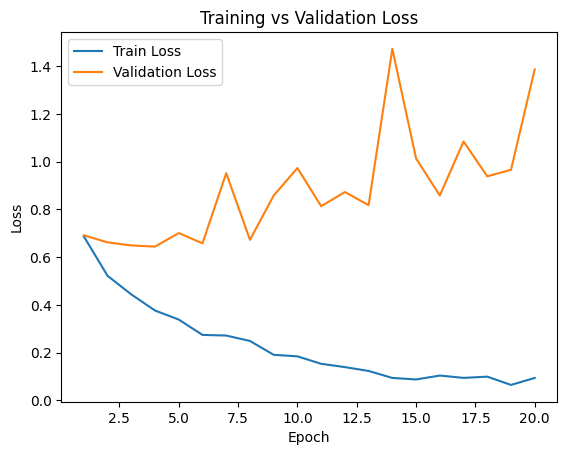

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

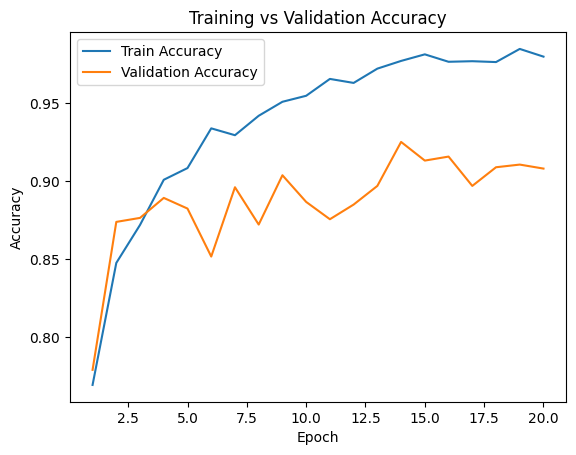

In [7]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

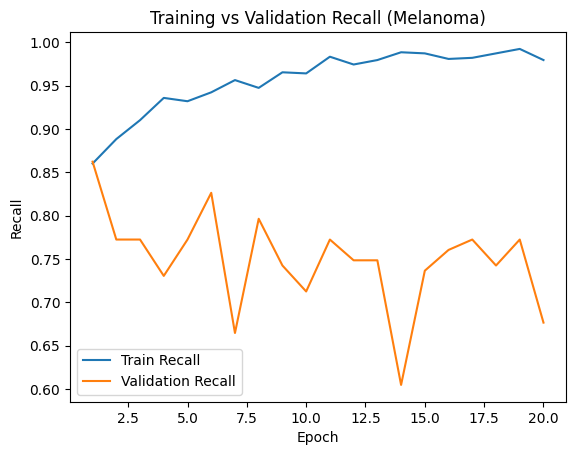

In [8]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

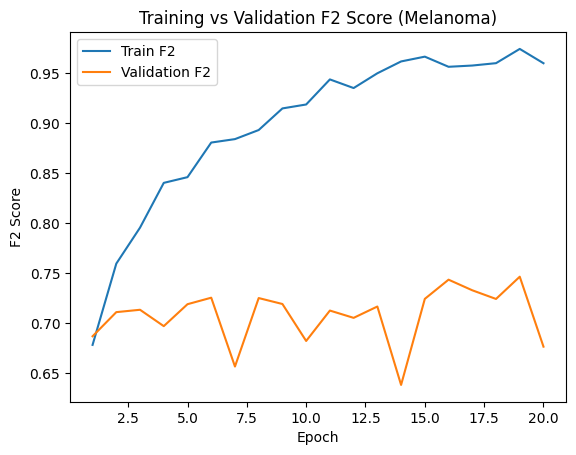

In [9]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [10]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('../models/resnet_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.13 | Val F2: 0.7843


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [12]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[904 102]
 [ 21 146]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [13]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9773    0.8986    0.9363      1006
           1     0.5887    0.8743    0.7036       167

    accuracy                         0.8951      1173
   macro avg     0.7830    0.8864    0.8200      1173
weighted avg     0.9220    0.8951    0.9032      1173



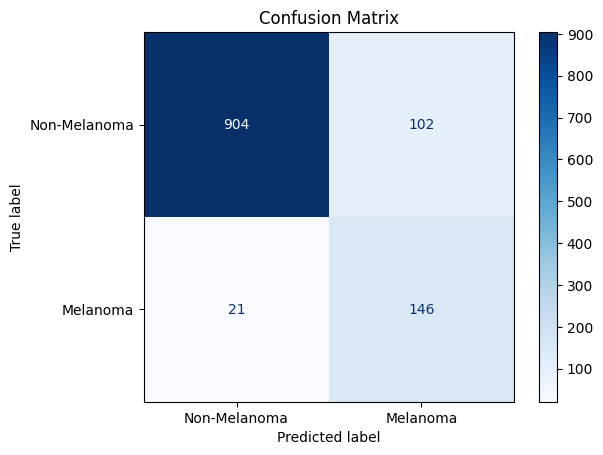

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()